Quick test to check if quantisation + STE seems to behave sensibly

In [1]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torch import nn

import quantisation
from quantisation.layers import quantise_linear_layers

In [2]:
x = torch.arange(-10, 10, step=1e-2)[:, None]
target = x**2

In [3]:
class SimpleNetwork(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.l1 = nn.Linear(1, hidden_dim, bias=True)
        self.l2 = nn.Linear(hidden_dim, 1, bias=True)

    def forward(self, x):
        return self.l2(F.relu(self.l1(x)))

In [4]:
def train(model, x, n_steps=1000, lr=1e-2):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(n_steps):
        opt.zero_grad()
        out = model(x)
        loss = ((out - target) ** 2).sum()
        loss.backward()
        opt.step()

In [5]:
model = SimpleNetwork(hidden_dim=64)
quant_model = quantise_linear_layers(
    model,
    weight_fmt=quantisation.tensor_scaling_format(
        element_format=quantisation.parse("E0M1")
    ),
)

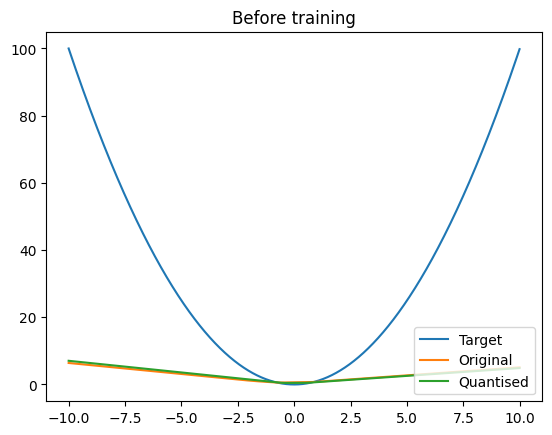

In [6]:
plt.title("Before training")
plt.plot(x, target, label="Target")
plt.plot(x, model(x).detach(), label="Original")
plt.plot(x, quant_model(x).detach(), label="Quantised")
plt.legend(loc="lower right")
plt.show()

In [7]:
train(model, x)

In [8]:
train(quant_model, x)

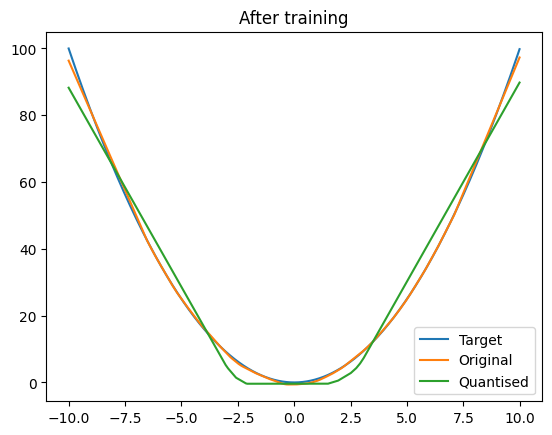

In [9]:
plt.title("After training")
plt.plot(x, target, label="Target")
plt.plot(x, model(x).detach(), label="Original")
plt.plot(x, quant_model(x).detach(), label="Quantised")
plt.legend(loc="lower right")
plt.show()
